# Particle 2: precision study of the return to its initial state

This notebook follows **only particle 2** (one-based label, array index `1`) from
`visualization.ipynb` in this directory. It reproduces the original physical data,
compares the archived BM4 trajectory with an independently integrated reference,
and resolves close approaches between saved times. It keeps the original **50
forcing cycles** and focuses the detailed view on the best archived integer-cycle
return, unless `target_cycle` is changed below.

**Run all cells with this project's `.venv` kernel.** The workflow is contained here;
there is no need to rerun either original notebook. It uses the existing `results.npz`,
the measured HDF5 field, and the project's Python modules. The precision calculation
is saved separately in `particle_2_precision_results.npz`; subsequent runs load that
file after checking input, configuration, implementation and library fingerprints.
Set `recompute = True` to regenerate it. An uncached run can take several minutes,
mainly for the independent Radau audit. The original archive is never overwritten.

## Physical model, units and the meaning of a return

The 20 trajectories in the source study are **independent guiding centres** in a
prescribed, time-periodic field. Extracting particle 2 therefore preserves its
physical ODE. With the project's gyroaveraged potential $\bar\Phi_\rho$,

$$\dot x=-\partial_y\bar\Phi_\rho(t,x,y),\qquad
\dot y=\partial_x\bar\Phi_\rho(t,x,y).$$

The physical GC state is $(x,y)$. Its drift velocity follows from this first-order
ODE; there is no independently specified initial velocity, mass, charge or
interaction between particles to introduce. The source uses `rho=0.3`, the measured
`PHI_2.h5` field, `B=1.5`, characteristic length $\lambda=0.06$, selectors `(0,1)`
(mean plus dominant mode), and cubic spatial interpolation on the source grid.
BM4's coupling frequency $\pi/8$ is a numerical composition parameter, not a
particle interaction; it does not enter the adaptive physical-ODE references.

Coordinates are dimensionless: $\hat x=2\pi(R-R_0)/\lambda$ and similarly for $y$.
One coordinate unit corresponds to $\lambda/(2\pi)$ in the HDF5 length units.
Time is $\hat t=t_{\rm physical}/T_0$, with $T_0=2\pi/\omega_0$ from the loader.
The retained mode has normalized frequency one, so integer times share the
initial forcing phase. Physical length and time conversions are shown below;
no extra units are inferred from undocumented HDF5 attributes.

Particle 2 is the second of 20 half-open horizontal samples from the cell centre
towards the right edge: $(x_0,y_0)=(x_{\min}+0.525L,y_{\min}+0.5L)$.
Here $L$ is the periodic-cell width, not the gyro-radius.

We measure $\delta(t)=\operatorname{minimum\_image}(z(t)-z_0)$ and
$d(t)=\|\delta(t)\|_2$. Two questions are kept separate:

1. **Same-phase return:** $d(n)$ at positive integers $n$, exactly as in the source
   notebook. Both position and forcing phase must recur for a return of the
   periodically driven state $(x\bmod L,y\bmod L,2\pi t\bmod2\pi)$.
2. **Spatial close approach:** a local minimum of $d(t)$ between cycles. Its time,
   phase offset and drift-velocity difference are reported. A small spatial
   distance at noninteger time does not establish recurrence of the driven state.

The search starts at $t=1$ to exclude the trivial initial return and match the
source's first inspected cycle. Closeness at a finite tolerance does not prove
an exact periodic orbit.

In [1]:
from dataclasses import asdict
from pathlib import Path
from types import SimpleNamespace
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import scipy

from diagnostics import load_parallel_bm4_recurrence_npz
from diagnostics.paths import find_project_root
from diagnostics.single_particle_recurrence import (
    export_recurrence_tables, load_recurrence, recurrence_identity, save_recurrence,
)
from dynamics import GuidingCenterDynamics
from potential import load_gc2d_h5_potential
from studies.single_particle_recurrence import (
    SingleParticleRecurrenceConfig, distance_to_initial, minimum_image,
    run_single_particle_recurrence,
)
from visualization.single_particle_recurrence import (
    display_recurrence_records as display_records_table,
    plot_particle_recurrence, plot_particle_reference_audit, plot_particle_return_zoom,
)

plt.rcParams.update({'figure.dpi': 115, 'axes.grid': True, 'grid.alpha': 0.22})

In [2]:
# Physical inputs are explicit and checked against the archived experiment.
particle_number = 2
potential_specification = {
    'source_path': 'data/potential/V1/PHI_2.h5',
    'magnetic_field': 1.5,
    'characteristic_length': 0.06,
    'mode_selection': [0, 1],
    'interpolation_order': 3,
}
source_particle_count = 20
source_steps_per_cycle = 80
source_saves_per_cycle = 20
source_coupling_frequency = float(np.pi / 8)
source_newton_atol, source_newton_rtol = 1e-12, 1e-11
source_newton_max_iterations = 40
source_jacobian_relative_step = float(np.cbrt(np.finfo(float).eps))

# Three independent integrations from t=0; all use IEEE-754 float64 arithmetic.
config = SingleParticleRecurrenceConfig(
    final_time=50.0, search_start=1.0, samples_per_cycle=200, rho=0.3,
    reference_rtol=1e-10, reference_atol=1e-12, reference_max_step=0.025,
    refined_rtol=1e-12, refined_atol=1e-14, refined_max_step=0.0125,
    audit_rtol=1e-13, audit_atol=1e-15, audit_max_step=0.00625,
    root_xtol=1e-11, threshold_fractions=(1e-2, 1e-3, 1e-4, 1e-5, 1e-6),
)
recompute = False
target_cycle = None  # None selects the closest original integer-cycle return.
zoom_half_width = 0.06

In [3]:
project_root = find_project_root(Path.cwd())
notebook_directory = project_root / 'notebooks/developements/recurrences/study_20_horizontal_bm4_recurrences'
source_path = notebook_directory / 'results.npz'
cache_path = notebook_directory / 'particle_2_precision_results.npz'
output_directory = notebook_directory / 'particle_2_precision_outputs'
stored = load_parallel_bm4_recurrence_npz(source_path)
source = stored.result
experiment = stored.metadata['experiment']
assert particle_number == 2 and source.config.particle_count == source_particle_count
assert experiment['potential'] == potential_specification
assert source.config.steps_per_cycle == source_steps_per_cycle
assert source.config.saved_samples_per_cycle == source_saves_per_cycle
assert source.config.rho == config.rho
assert source.config.coupling_frequency == source_coupling_frequency
assert source.config.absolute_tolerance == source_newton_atol
assert source.config.relative_tolerance == source_newton_rtol
assert source.config.max_iterations == source_newton_max_iterations
assert source.config.jacobian_relative_step == source_jacobian_relative_step
assert source.config.t_span == (0., 50.)
assert config.final_time <= source.config.t_span[1]

data_path = project_root / potential_specification['source_path']
potential = load_gc2d_h5_potential(
    data_path, B=potential_specification['magnetic_field'],
    characteristic_length=potential_specification['characteristic_length'],
    indx=tuple(potential_specification['mode_selection']),
    interpolation_order=potential_specification['interpolation_order'],
)
period = float(potential.grid.period)
initial_state = source.initial_positions[particle_number - 1].copy()
expected_initial = np.array([
    potential.grid.xmin + period * (0.5 + 1 / (2 * source_particle_count)),
    potential.grid.ymin + period * 0.5,
])
np.testing.assert_allclose(initial_state, expected_initial, rtol=0, atol=2e-14 * period)
np.testing.assert_allclose(potential.frequencies, [1.], rtol=0, atol=1e-14)
source_mask = source.times <= config.final_time
original_times = source.times[source_mask]
original_states = source.positions[particle_number - 1][:, source_mask]
assert original_states.shape == (2, original_times.size)
np.testing.assert_array_equal(original_states[:, 0], initial_state)

length_unit = potential_specification['characteristic_length'] / (2 * np.pi)
time_unit = potential.metadata.characteristic_period
dynamics = GuidingCenterDynamics(potential, rho=config.rho)
print(f'Particle {particle_number}; archive index {particle_number - 1}')
print(f'Initial state: x={initial_state[0]:.16g}, y={initial_state[1]:.16g}')
print(f'Initial drift velocity: {dynamics.vector_field(0., initial_state)}')
print(f'Cell width L={period:.16g}; source grid={potential.grid.shape}')
print(f'One distance unit = {length_unit:.12g} in source length units')
print(f'One time unit = {time_unit:.12g} in source time units')
print(f'Runtime frequencies={potential.frequencies}; original HDF5 mode indices={potential.metadata.source_field_indices}')
print(f'Python {sys.version.split()[0]}, NumPy {np.__version__}, SciPy {scipy.__version__}')
print(f'float64 epsilon = {np.finfo(np.float64).eps:.6e}')

Particle 2; archive index 1
Initial state: x=9.89601685880335, y=9.424777960765095
Initial drift velocity: [ 0.27141849 -0.27079127]
Cell width L=18.84955592153019; source grid=(256, 256)
One distance unit = 0.00954929658551 in source length units
One time unit = 0.00261352184253 in source time units
Runtime frequencies=[1.]; original HDF5 mode indices=[15]
Python 3.11.10, NumPy 1.26.4, SciPy 1.17.1
float64 epsilon = 2.220446e-16


## The return seen in the original notebook

These distances are measured from particle 2's own initial point using the same
minimum-image convention. The archived integration took steps of `0.0125`, but
saved only every `0.05`; a smaller output interval alone would not improve the
integration. The table below uses exact integer-cycle samples and excludes zero.

In [4]:
source_cycle_indices = np.arange(source_saves_per_cycle, len(original_times), source_saves_per_cycle)
source_cycle_times = original_times[source_cycle_indices]
np.testing.assert_allclose(source_cycle_times, np.arange(1, int(config.final_time) + 1), rtol=0, atol=1e-12)
source_cycle_distances = distance_to_initial(original_states[:, source_cycle_indices], initial_state, period)
best_source_index = int(np.argmin(source_cycle_distances))
if target_cycle is None:
    target_cycle = int(round(source_cycle_times[best_source_index]))
if not 1 <= target_cycle <= int(config.final_time):
    raise ValueError('target_cycle must be an integer cycle inside the integration horizon.')
assert int(target_cycle) == target_cycle
source_rows = [SimpleNamespace(cycle=int(source_cycle_times[i]),
                              distance=float(source_cycle_distances[i]),
                              fraction=float(source_cycle_distances[i] / period))
               for i in np.argsort(source_cycle_distances)[:10]]
display_records_table(source_rows, columns=(
    ('cycle', 'Original cycle', 'd'), ('distance', 'Original BM4 distance', '.10e'),
    ('fraction', 'Distance / L', '.10e'),
))
print(f'Detailed view: cycle {target_cycle}, window +/- {zoom_half_width:g} cycles.')

Original cycle,Original BM4 distance,Distance / L
36,8.5757583032e-03,4.5495810824e-04
29,4.2940448384e-02,2.2780615396e-03
7,5.5972864423e-02,2.9694526840e-03
43,6.8666882079e-02,3.6428912365e-03
22,9.9526989603e-02,5.2800707888e-03
14,1.3034945665e-01,6.9152534515e-03
50,1.4901433159e-01,7.9054558213e-03
15,1.5795608956e-01,8.3798308150e-03
44,1.9392847812e-01,1.0288225300e-02
8,2.0042309235e-01,1.0632775286e-02


Detailed view: cycle 36, window +/- 0.06 cycles.


## Reference calculation and numerical precision

The refined DOP853 solution is the working reference. A coarser DOP853 solve
tests step/tolerance refinement; a tighter Radau solve audits a different solver
family with the analytic GC Jacobian. **Every solve integrates from $t=0$ and the
original initial state**, so the refinement does not inherit an archived BM4
position error near the return.

This is a focused return-localization study, rather than a comparison campaign of
five fourth-order methods. It retains the project's DOP853/Radau physical-ODE
reference strategy and adds continuous solver output: the existing sampled-only
reference exporter does not retain the dense interpolants needed for event timing.
Runtime records describe these solves and are not a comparative timing benchmark.

The table records internal maximum steps and local error tolerances separately
from the saved interval `1/200`. All calculations, including the field interpolation,
use `float64`; tight tolerances do not create arbitrary-precision arithmetic or
guarantee the same number of correct trajectory digits. The study resolves the
same interpolated ODE; it does not quantify measurement error, spatial interpolation
error or error in the guiding-centre physical approximation.

Spatial minima satisfy $\delta\cdot f(t,z(t))=0$ with a negative-to-positive crossing.
Dense solver output and a bracketed root solve refine their times. Bracket searches
at `1/200` and `1/400` audit missed minima. Root `xtol=1e-11` controls the scalar
solve, not the uncertainty of the integrated return time. Endpoints are checked
separately. These finite-mesh checks provide numerical evidence, not a proof that
all possible tangencies have been found. The tables expose both mesh sensitivity
and independent-solver differences.

No analytic solution is known here for this measured field. The return detector
has an independent circular-orbit test with exact return times and exact threshold
entry/exit times in `tests/test_single_particle_recurrence.py`. No energy-conservation
test is used to certify the trajectory; this potential is time dependent.

Method references: [SciPy solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)
and [bracketed Brent root finding](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html).
The physical sign convention and normalization are defined in the project's
`src/dynamics/gc.py` and `src/potential/gc2d_h5.py`.

In [5]:
identity = recurrence_identity(
    project_root, source_archive=source_path, potential_path=data_path,
    initial=initial_state, config=asdict(config), potential_specification=potential_specification,
)
if cache_path.is_file() and not recompute:
    arrays, analysis = load_recurrence(cache_path, identity)
    print(f'Loaded validated precision calculation: {cache_path.name}')
else:
    arrays, analysis = run_single_particle_recurrence(potential, initial_state, config=config)
    save_recurrence(cache_path, arrays, analysis, identity)
    print(f'Saved precision calculation: {cache_path.name}')

np.testing.assert_array_equal(arrays['initial_state'], initial_state)
assert arrays['DOP853_refined.states'].shape == (2, int(config.final_time * config.samples_per_cycle) + 1)
assert all(row['search_counts_agree'] for row in analysis['solvers'].values()), 'Search-mesh refinement found additional minima.'
assert all(row['search_maximum_time_shift'] is None or row['search_maximum_time_shift'] < 1e-7
           for row in analysis['solvers'].values()), 'Return times are sensitive to the search mesh.'
solver_rows = [SimpleNamespace(label=label, **row) for label, row in analysis['solvers'].items()]
display_records_table(solver_rows, columns=(
    ('label', 'Solver', ''), ('rtol', 'rtol', '.1e'), ('atol', 'atol', '.1e'),
    ('max_step', 'Maximum step', '.6f'), ('accepted_steps', 'Accepted steps', 'd'),
    ('nfev', 'RHS evaluations', 'd'), ('runtime_seconds', 'Recorded runtime [s]', '.2f'),
    ('search_count', 'Minima: base mesh', 'd'), ('refined_search_count', 'Minima: half mesh', 'd'),
))
for label in ('DOP853', 'Radau'):
    discrepancy = arrays[label + '.reference_discrepancy']
    print(f'{label} vs refined: max={np.max(discrepancy):.6e}, RMS={np.sqrt(np.mean(discrepancy**2)):.6e}')

Loaded validated precision calculation: particle_2_precision_results.npz


Solver,rtol,atol,Maximum step,Accepted steps,RHS evaluations,Recorded runtime [s],Minima: base mesh,Minima: half mesh
DOP853,1.0e-10,1.0e-12,0.025000,2063,32903,41.58,52,52
DOP853_refined,1.0e-12,1.0e-14,0.012500,4363,73871,77.01,52,52
Radau,1.0e-13,1.0e-15,0.006250,50210,355094,392.34,52,52


DOP853 vs refined: max=6.556733e-07, RMS=2.066246e-07
Radau vs refined: max=2.969800e-08, RMS=1.058769e-08


## Particle 2 over the complete horizon

The left view uses periodic displacement from the initial point; the dashed circle
is the original 1% cell-width threshold. Integer-time dots have the initial forcing
phase. Downward triangles in the right view are spatial minima resolved between
output samples. Only particle 2 is shown.

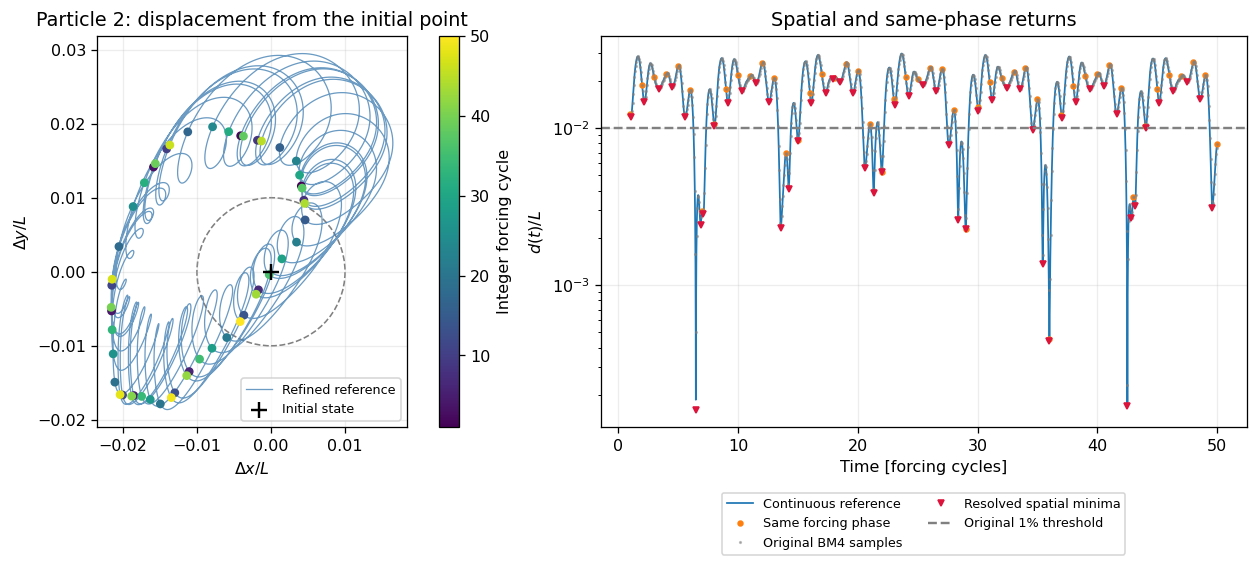

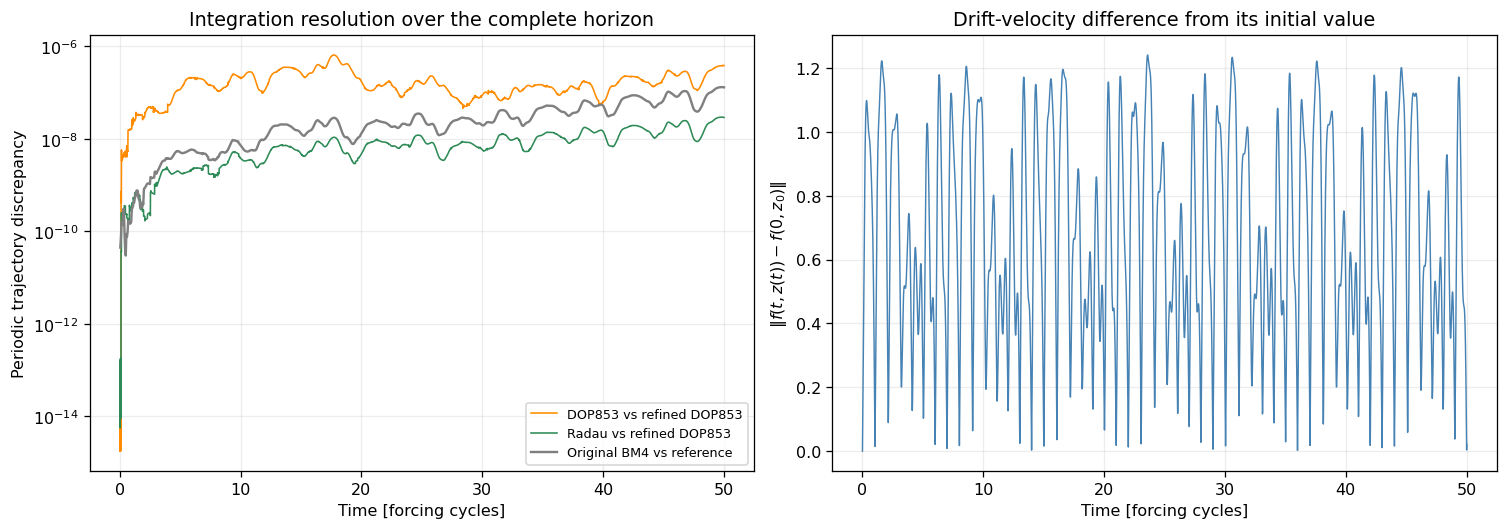

In [6]:
trajectory_figure = plot_particle_recurrence(arrays, analysis, original_times, original_states)
plt.show()
audit_figure = plot_particle_reference_audit(arrays, analysis, original_times, original_states)
plt.show()

## Same-phase returns: reference versus the original BM4 archive

`Reference discrepancy` is the larger of the two solver differences at the same
time. It is an empirical resolution scale, not a proven bound or a confidence
interval. The original BM4 trajectory is identified by its archive checksum;
the archive does not preserve a full fingerprint of its historical solver code.

In [7]:
cycle_times = arrays['cycle_times']
cycle_states = arrays['DOP853_refined.cycle_states']
cycle_delta = minimum_image(cycle_states - initial_state[:, None], period)
cycle_distances = np.linalg.norm(cycle_delta, axis=0)
cycle_indices = np.rint(cycle_times * config.samples_per_cycle).astype(int)
np.testing.assert_allclose(arrays['times'][cycle_indices], cycle_times, rtol=0, atol=1e-12)
bm4_errors = np.linalg.norm(minimum_image(original_states[:, source_cycle_indices] - cycle_states, period), axis=0)
cycle_rows = [dict(
    cycle=int(cycle_times[i]), bm4_distance=float(source_cycle_distances[i]),
    reference_distance=float(cycle_distances[i]), cell_fraction=float(cycle_distances[i] / period),
    dx=float(cycle_delta[0, i]), dy=float(cycle_delta[1, i]), bm4_trajectory_error=float(bm4_errors[i]),
    reference_discrepancy=float(arrays['reference_floor'][cycle_indices[i]]),
    velocity_difference=float(arrays['velocity_difference'][cycle_indices[i]]),
) for i in range(len(cycle_times))]
display_records_table([SimpleNamespace(**r) for r in sorted(cycle_rows, key=lambda r: r['reference_distance'])[:12]], columns=(
    ('cycle', 'Cycle', 'd'), ('bm4_distance', 'Original BM4 distance', '.10e'),
    ('reference_distance', 'Reference distance', '.10e'), ('cell_fraction', 'Distance / L', '.6e'),
    ('bm4_trajectory_error', 'BM4 trajectory error', '.6e'),
    ('reference_discrepancy', 'Reference discrepancy', '.3e'),
))

Cycle,Original BM4 distance,Reference distance,Distance / L,BM4 trajectory error,Reference discrepancy
36,8.5757583032e-03,8.5758076847e-03,4.549607e-04,4.950758e-08,1.120e-07
29,4.2940448384e-02,4.2940421882e-02,2.278060e-03,2.705895e-08,6.030e-08
7,5.5972864423e-02,5.5972869156e-02,2.969453e-03,4.828677e-09,1.854e-07
43,6.8666882079e-02,6.8666964862e-02,3.642896e-03,8.329136e-08,2.060e-07
22,9.9526989603e-02,9.9526967643e-02,5.280070e-03,2.243933e-08,1.591e-07
14,1.3034945665e-01,1.3034947583e-01,6.915254e-03,1.964263e-08,3.539e-07
50,1.4901433159e-01,1.4901446249e-01,7.905463e-03,1.309781e-07,3.871e-07
15,1.5795608956e-01,1.5795608151e-01,8.379830e-03,1.309993e-08,2.669e-07
44,1.9392847812e-01,1.9392843698e-01,1.028822e-02,5.504129e-08,1.426e-07
8,2.0042309235e-01,2.0042309168e-01,1.063278e-02,3.688237e-09,1.169e-07


## Resolve the selected return in continuous time

The scalar return search does not interpolate the sparse BM4 archive. It uses the
new reference's continuous solution. In the spatial panel, the line joining the
initial point to a minimum is perpendicular to the local drift, up to the displayed
stationarity residual. An integer return and the adjacent spatial minimum are
different observables.

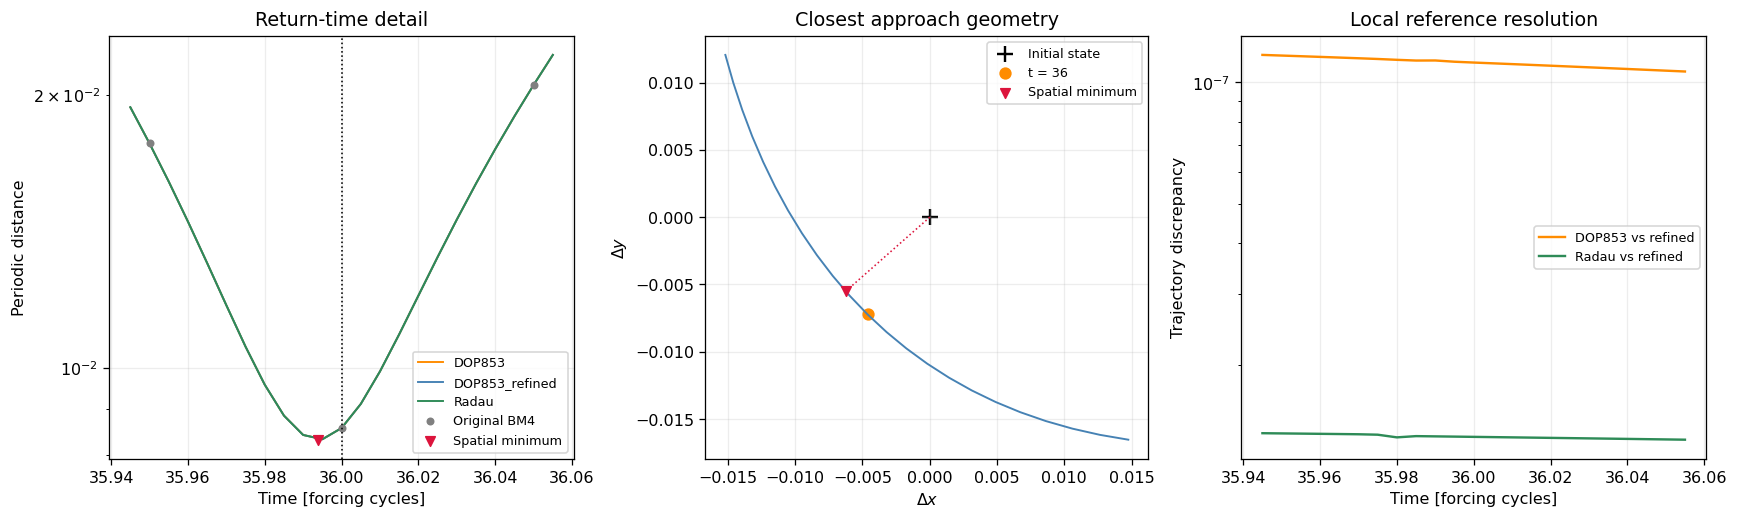

Spatial minimum time,Distance,Delta x,Delta y,Forcing phase offset [cycles],Drift-velocity difference,Reference discrepancy
35.993848375877,8.3252330419e-03,-6.2468087067e-03,-5.5033522678e-03,-6.151624123e-03,2.493325e-02,1.128e-07


t=35.993848375877: stationarity residual=5.998e-16, DOP853 return-time shift=2.9324619532644647e-07, Radau return-time shift=1.3488353545199061e-08
Converted displacement distance=7.9500119461e-05 in source length units; time=9.4070708927e-02 in source time units


In [8]:
zoom_figure = plot_particle_return_zoom(arrays, analysis, original_times, original_states,
                                      target_cycle=target_cycle, half_width=zoom_half_width)
plt.show()
focus_returns = [r for r in analysis['returns'] if abs(r['time'] - target_cycle) <= zoom_half_width]
display_records_table([SimpleNamespace(**r) for r in focus_returns], columns=(
    ('time', 'Spatial minimum time', '.12f'), ('distance', 'Distance', '.10e'),
    ('dx', 'Delta x', '.10e'), ('dy', 'Delta y', '.10e'),
    ('phase_offset_cycles', 'Forcing phase offset [cycles]', '.9e'),
    ('velocity_difference', 'Drift-velocity difference', '.6e'),
    ('reference_discrepancy', 'Reference discrepancy', '.3e'),
))
for row in focus_returns:
    print(f"t={row['time']:.12f}: stationarity residual={row['stationarity_residual']:.3e}, "
          f"DOP853 return-time shift={row['dop853_time_shift']}, Radau return-time shift={row['radau_time_shift']}")
    print(f"Converted displacement distance={row['distance'] * length_unit:.10e} in source length units; "
          f"time={row['time'] * time_unit:.10e} in source time units")

## Closest spatial approaches anywhere in the search interval

This ranking can select a different cycle from the integer-time ranking. Return
times are displayed with extra digits to expose numerical differences, not to
claim those digits are all accurate. Compare time shifts and the reference
discrepancy before interpreting very small distances.

In [9]:
ranked_returns = sorted(analysis['returns'], key=lambda r: r['distance'])
display_records_table([SimpleNamespace(**r) for r in ranked_returns[:12]], columns=(
    ('time', 'Time', '.12f'), ('distance', 'Distance', '.10e'),
    ('cell_fraction', 'Distance / L', '.6e'),
    ('phase_offset_cycles', 'Phase offset [cycles]', '.8f'),
    ('reference_discrepancy', 'Reference discrepancy', '.3e'),
))
print(f"Closest spatial time including interval boundaries: {analysis['closest_spatial_time']:.12f}")
print(f"Selected point is a search boundary: {analysis['closest_spatial_is_boundary']}")

Time,Distance,Distance / L,Phase offset [cycles],Reference discrepancy
6.487401086002,3.0414834009e-03,1.613557e-04,0.48740109,2.021e-07
42.504229613250,3.2083163887e-03,1.702065e-04,-0.49577039,2.235e-07
35.993848375877,8.3252330419e-03,4.416673e-04,-0.00615162,1.128e-07
35.433163404858,2.5802616270e-02,1.368871e-03,0.43316340,1.366e-07
29.004062596427,4.2876249324e-02,2.274656e-03,0.00406260,6.048e-08
13.581274136552,4.3607990762e-02,2.313476e-03,-0.41872586,3.549e-07
6.879055685304,4.5635721688e-02,2.421050e-03,-0.12094431,1.951e-07
28.381100938897,4.9295431101e-02,2.615204e-03,0.38110094,5.593e-08
42.839463569784,5.0477750080e-02,2.677928e-03,-0.16053643,2.162e-07
7.119010293692,5.3179384982e-02,2.821254e-03,0.11901029,1.728e-07


Closest spatial time including interval boundaries: 6.487401086002
Selected point is a search boundary: False


## How close, and for how long?

For each radius, the table counts spatial visits and integer-cycle returns.
Entry/exit times are root-refined on the reference. Resolved minima are inserted
into the bracketing mesh, so a short visit can be detected even when both adjacent
saved samples lie outside the ball. A boundary-censored visit starts or ends at
the search limit, so its reported duration is only the observed portion. All
intervals are exported to CSV; a tangential touch with zero residence time is not
counted as a visit. Classification close to a threshold remains sensitive to the
reported reference discrepancy.

In [10]:
threshold_rows = [SimpleNamespace(
    fraction=row['fraction'], radius=row['radius'], visits=len(row['windows']),
    integer_returns=len(row['integer_times_inside']), cycles=str(row['integer_times_inside']),
) for row in analysis['thresholds']]
display_records_table(threshold_rows, columns=(
    ('fraction', 'Threshold / L', '.1e'), ('radius', 'Radius', '.8e'),
    ('visits', 'Spatial visits', 'd'), ('integer_returns', 'Same-phase returns', 'd'),
    ('cycles', 'Integer return times', ''),
))
focus_windows = [SimpleNamespace(fraction=row['fraction'], **window)
                 for row in analysis['thresholds'] for window in row['windows']
                 if window['entry'] <= target_cycle + zoom_half_width
                 and window['exit'] >= target_cycle - zoom_half_width]
display_records_table(focus_windows, columns=(
    ('fraction', 'Threshold / L', '.1e'), ('entry', 'Entry time', '.12f'),
    ('exit', 'Exit time', '.12f'), ('duration', 'Observed duration', '.10e'),
    ('entry_censored', 'Left censored', ''), ('exit_censored', 'Right censored', ''),
))

Threshold / L,Radius,Spatial visits,Same-phase returns,Integer return times
1.0e-02,1.88495559e-01,12,8,"[7.0, 14.0, 15.0, 22.0, 29.0, 36.0, 43.0, 50.0]"
1.0e-03,1.88495559e-02,3,1,[36.0]
1.0e-04,1.88495559e-03,0,0,[]
1.0e-05,1.88495559e-04,0,0,[]
1.0e-06,1.88495559e-05,0,0,[]


Threshold / L,Entry time,Exit time,Observed duration,Left censored,Right censored
1.0e-02,35.238571245342,36.302093097304,1.0635218520e+00,False,False
1.0e-03,35.946571747559,36.044668549953,9.8096802394e-02,False,False


## Conclusions derived from this calculation

In [11]:
best_cycle_row = min(cycle_rows, key=lambda r: r['reference_distance'])
selected_cycle_row = next(r for r in cycle_rows if r['cycle'] == target_cycle)
summary_lines = [
    f"- **Best same-phase return:** cycle **{best_cycle_row['cycle']}**, periodic distance "
    f"`{best_cycle_row['reference_distance']:.8e}` = `{best_cycle_row['cell_fraction']:.8e} L`.",
    f"- **Selected cycle {target_cycle}:** original BM4 distance `{selected_cycle_row['bm4_distance']:.8e}`; "
    f"reference distance `{selected_cycle_row['reference_distance']:.8e}`; "
    f"reference discrepancy `{selected_cycle_row['reference_discrepancy']:.3e}`.",
]
if focus_returns:
    selected = min(focus_returns, key=lambda r: r['distance'])
    summary_lines.append(
        f"- **Closest spatial approach near cycle {target_cycle}:** time `{selected['time']:.10f}`, "
        f"distance `{selected['distance']:.8e}`, phase offset "
        f"`{selected['phase_offset_cycles']:.8e}` cycles. "
        f"Distance decreases by `{100 * (1 - selected['distance'] / selected_cycle_row['reference_distance']):.3f}%` "
        "relative to the integer-cycle sample."
    )
if ranked_returns:
    best = ranked_returns[0]
    summary_lines.append(
        f"- **Best detected interior spatial minimum in [{config.search_start:g}, {config.final_time:g}]:** "
        f"time `{best['time']:.10f}`, distance `{best['distance']:.8e}`; phase offset "
        f"`{best['phase_offset_cycles']:.8e}` cycles."
    )
    resolved = best['distance'] > 10 * best['reference_discrepancy']
    summary_lines.append(
        "- **Resolution assessment:** the minimum distance exceeds ten times the measured solver discrepancy; "
        "its nonzero separation is resolved by this numerical audit."
        if resolved else
        "- **Resolution assessment:** the minimum is comparable to the solver discrepancy; "
        "this calculation cannot resolve its nonzero separation reliably."
    )
summary_lines.append(
    "- **Interpretation:** a near return is a finite-tolerance observation. The data do not establish "
    "an exact return or periodicity. A spatial minimum at noninteger time must also be checked against the forcing phase."
)
display(Markdown('\n'.join(summary_lines)))

- **Best same-phase return:** cycle **36**, periodic distance `8.57580768e-03` = `4.54960728e-04 L`.
- **Selected cycle 36:** original BM4 distance `8.57575830e-03`; reference distance `8.57580768e-03`; reference discrepancy `1.120e-07`.
- **Closest spatial approach near cycle 36:** time `35.9938483759`, distance `8.32523304e-03`, phase offset `-6.15162412e-03` cycles. Distance decreases by `2.922%` relative to the integer-cycle sample.
- **Best detected interior spatial minimum in [1, 50]:** time `6.4874010860`, distance `3.04148340e-03`; phase offset `4.87401086e-01` cycles.
- **Resolution assessment:** the minimum distance exceeds ten times the measured solver discrepancy; its nonzero separation is resolved by this numerical audit.
- **Interpretation:** a near return is a finite-tolerance observation. The data do not establish an exact return or periodicity. A spatial minimum at noninteger time must also be checked against the forcing phase.

## Reproducible outputs

The archive retains all three trajectories, all resolved minima and their states,
reference discrepancies, complete threshold intervals, and numerical controls.
The CSV files contain every detected event, not just the table excerpts above.
Figures are exported as PNG and SVG. Input SHA-256 values and code fingerprints
are included in the metadata. Re-execution replaces only this notebook's outputs.

In [12]:
export_recurrence_tables(output_directory, analysis, cycle_rows, identity)
for name, figure in (('trajectory_and_returns', trajectory_figure),
                     ('reference_audit', audit_figure), ('selected_return', zoom_figure)):
    for extension in ('png', 'svg'):
        figure.savefig(output_directory / f'{name}.{extension}', dpi=180, bbox_inches='tight')
(output_directory / 'conclusions.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
print(f'Precision archive: {cache_path}')
print(f'CSV tables, metadata and figures: {output_directory}')

Precision archive: /home/juan/Proyectos/GC2D_intranet/notebooks/developements/recurrences/study_20_horizontal_bm4_recurrences/particle_2_precision_results.npz
CSV tables, metadata and figures: /home/juan/Proyectos/GC2D_intranet/notebooks/developements/recurrences/study_20_horizontal_bm4_recurrences/particle_2_precision_outputs
